In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from mpl_toolkits.mplot3d import Axes3D

# Настройка качественного отображения графиков в Colab
%config InlineBackend.figure_format = 'retina'

In [2]:
# Параметры системы
l1, l2 = 1.0, 0.15
m1, m2, m3 = 5.0, 1.5, 0.5
T_end = 2.0

In [3]:
# Целевая траектория
def get_target(t):
    c = [
        [np.pi/4, 0, 0, 25*np.pi/48, -25*np.pi/64, 5*np.pi/64],    # q1
        [0.1, 0, 0, 0.25, -0.1875, 0.0375],                       # q2
        [np.pi/2, 0, 0, -5*np.pi/12, 5*np.pi/16, -np.pi/16]       # q3
    ]
    qd, dqd, ddqd = [], [], []
    for i in range(3):
        qd.append(c[i][0] + c[i][3]*t**3 + c[i][4]*t**4 + c[i][5]*t**5)
        dqd.append(3*c[i][3]*t**2 + 4*c[i][4]*t**3 + 5*c[i][5]*t**4)
        ddqd.append(6*c[i][3]*t + 12*c[i][4]*t**2 + 20*c[i][5]*t**3)
    return np.array(qd), np.array(dqd), np.array(ddqd)

def forward_kinematics(q):
    q1, q2, q3 = q
    x = -(l2 * np.cos(q3) + q2) * np.sin(q1)
    y = (l2 * np.cos(q3) + q2) * np.cos(q1)
    z = l1 + l2 * np.sin(q3)
    return np.array([x, y, z])

def get_dynamics_matrices(q, dq):
    q1, q2, q3 = q
    dq1, dq2, dq3 = dq

    # Матрица масс M(q)
    M = np.zeros((3, 3))
    M[0, 0] = m2 * q2**2 + m3 * (q2 + l2 * np.cos(q3))**2
    M[1, 1] = m2 + m3
    M[1, 2] = -m3 * l2 * np.sin(q3)
    M[2, 1] = -m3 * l2 * np.sin(q3)
    M[2, 2] = m3 * l2**2

    # Вектор центробежных и кориолисовых сил C(q, dq)*dq
    C_vec = np.zeros(3)
    C_vec[0] = 2*(m2*q2 + m3*(q2 + l2*np.cos(q3)))*dq1*dq2 - 2*m3*l2*(q2 + l2*np.cos(q3))*np.sin(q3)*dq1*dq3
    C_vec[1] = -(m2*q2 + m3*(q2 + l2*np.cos(q3)))*dq1**2 - m3*l2*dq3**2*np.cos(q3)
    C_vec[2] = m3*l2*(q2 + l2*np.cos(q3))*np.sin(q3)*dq1**2
    return M, C_vec

def robot_ode(t, state, method):
    q, dq = state[:3], state[3:]
    qd, dqd, ddqd = get_target(t)
    M, C_vec = get_dynamics_matrices(q, dq)
    e, de = qd - q, dqd - dq

    if method == 'inverse_dynamics':
        Kp, Kd = np.diag([400, 400, 400]), np.diag([40, 40, 40])
        u = ddqd + Kd @ de + Kp @ e
        tau = M @ u + C_vec
    elif method == 'lyapunov':
        Lambda, Ks = np.diag([20, 20, 20]), np.diag([100, 100, 100])
        s = de + Lambda @ e
        dqr = dqd + Lambda @ e
        ddqr = ddqd + Lambda @ de
        tau = M @ ddqr + C_vec + Ks @ s

    ddq = np.linalg.solve(M, tau - C_vec)
    return np.concatenate((dq, ddq))

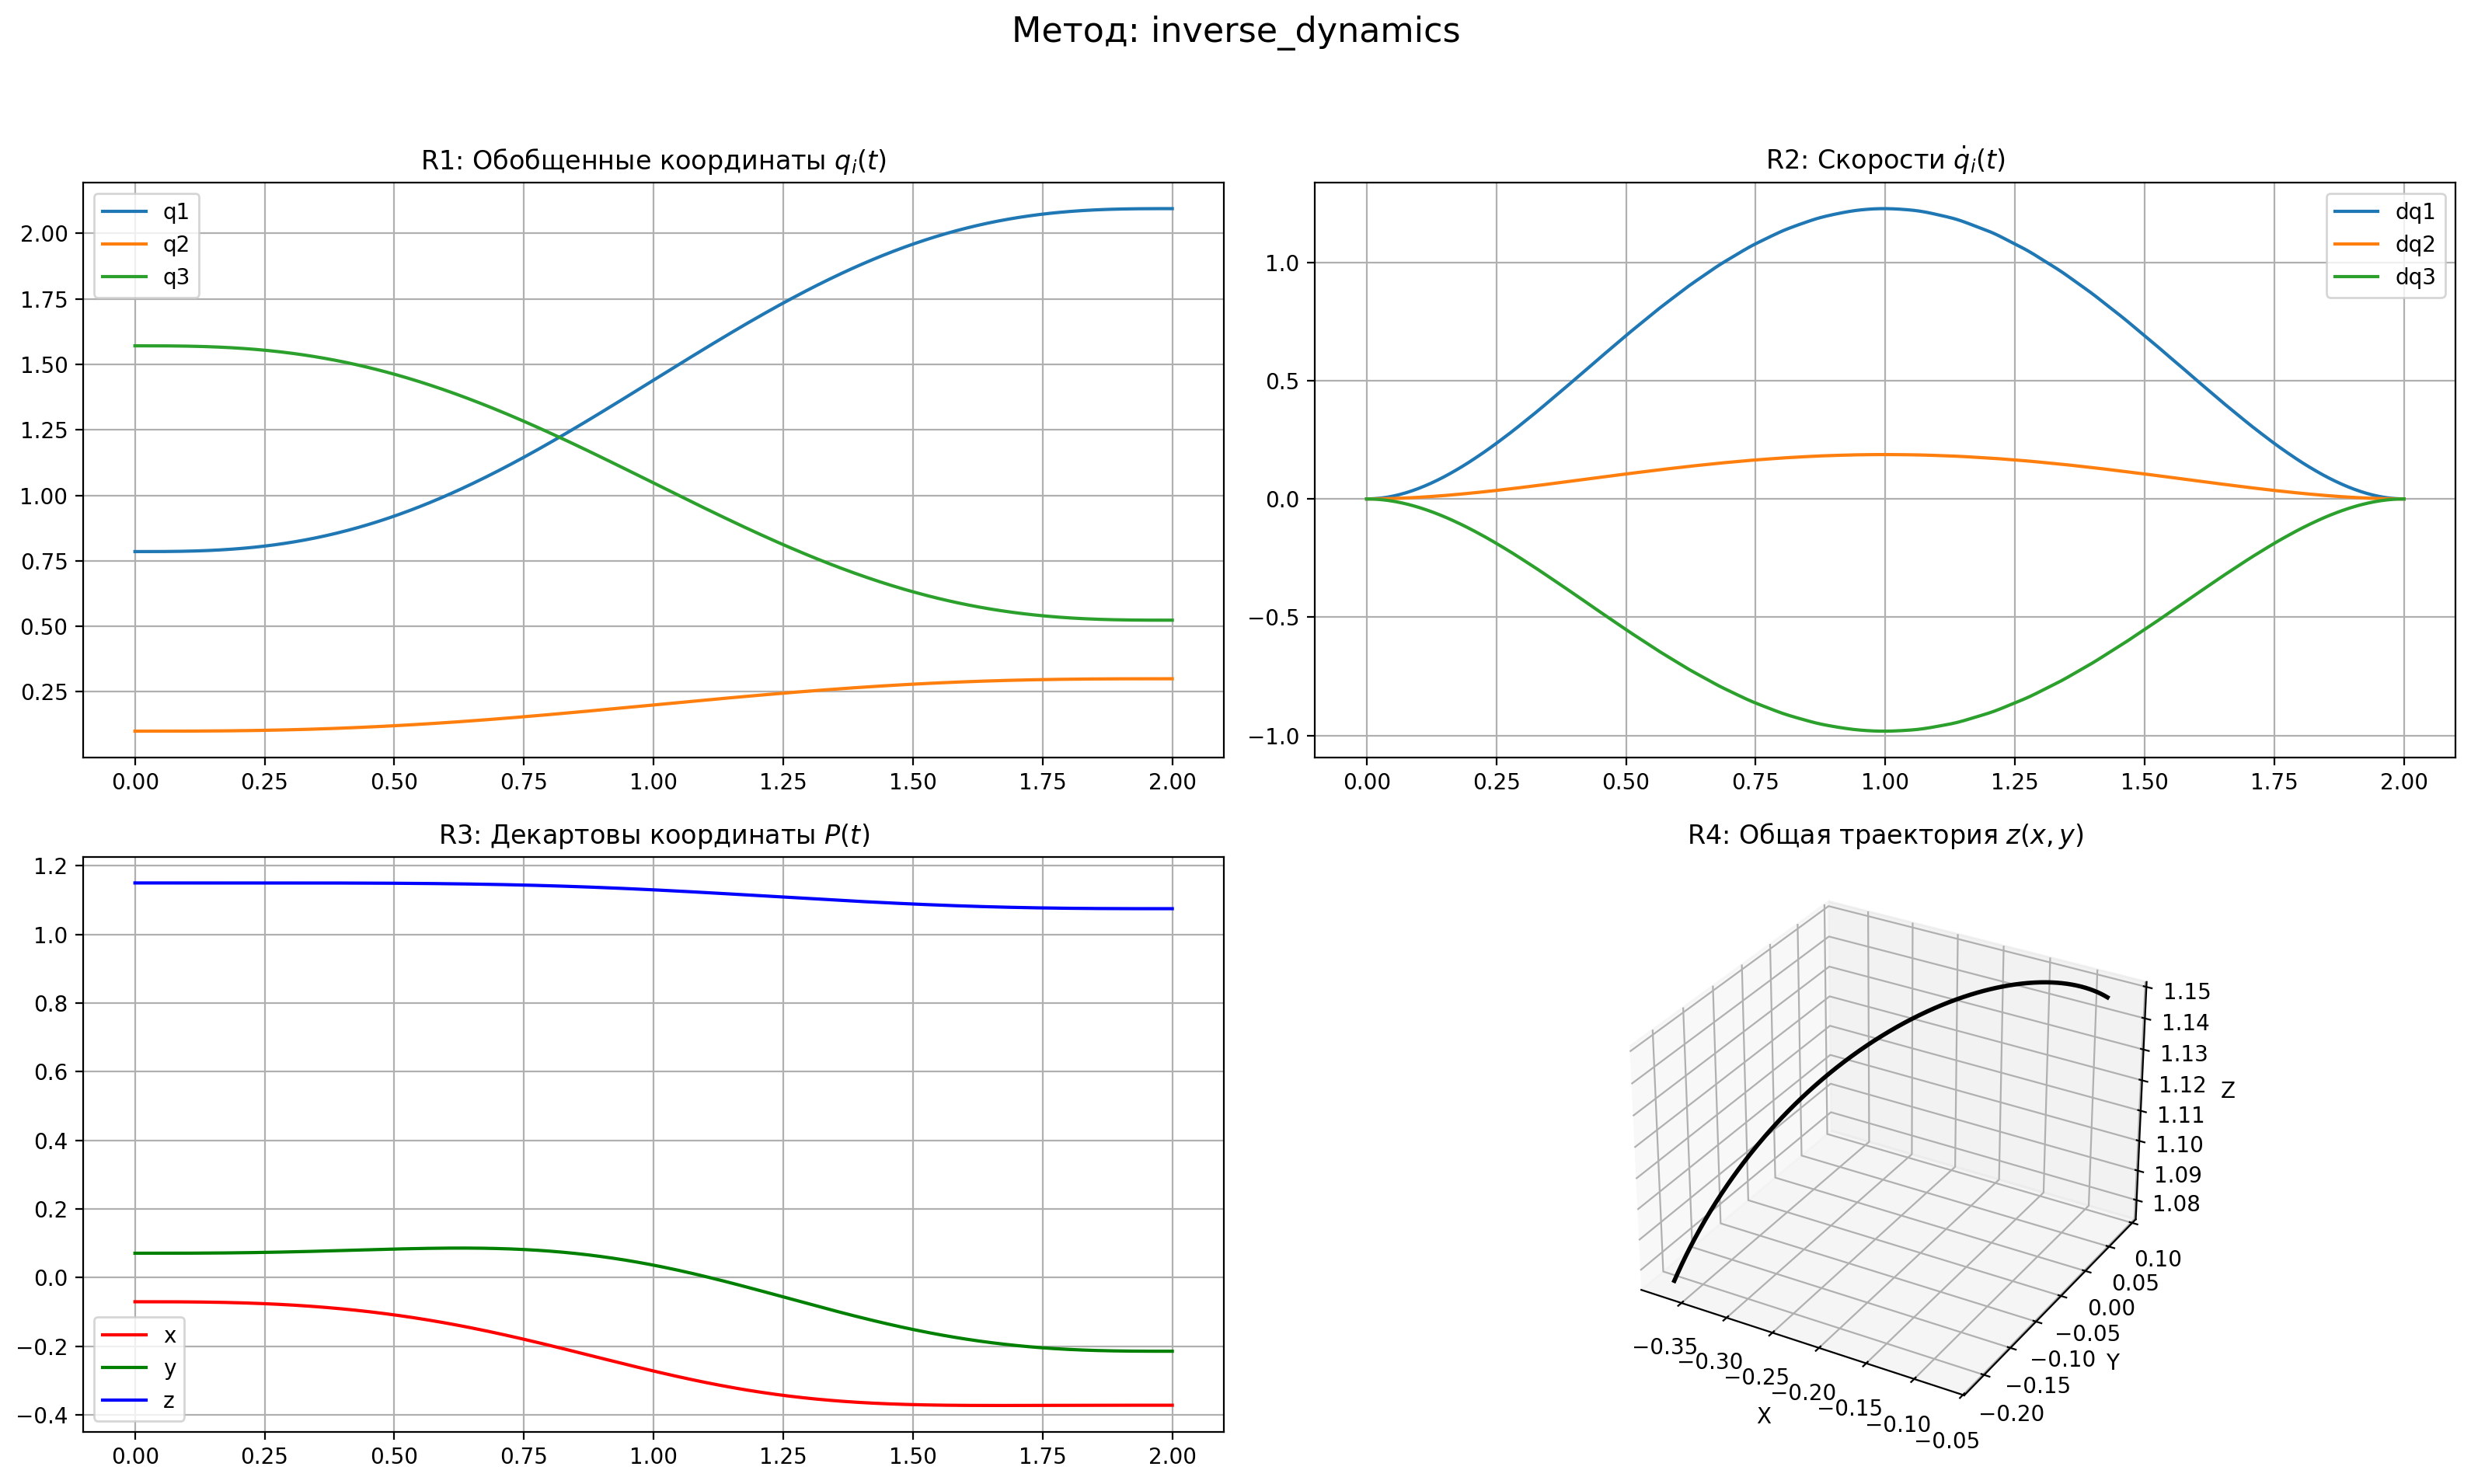

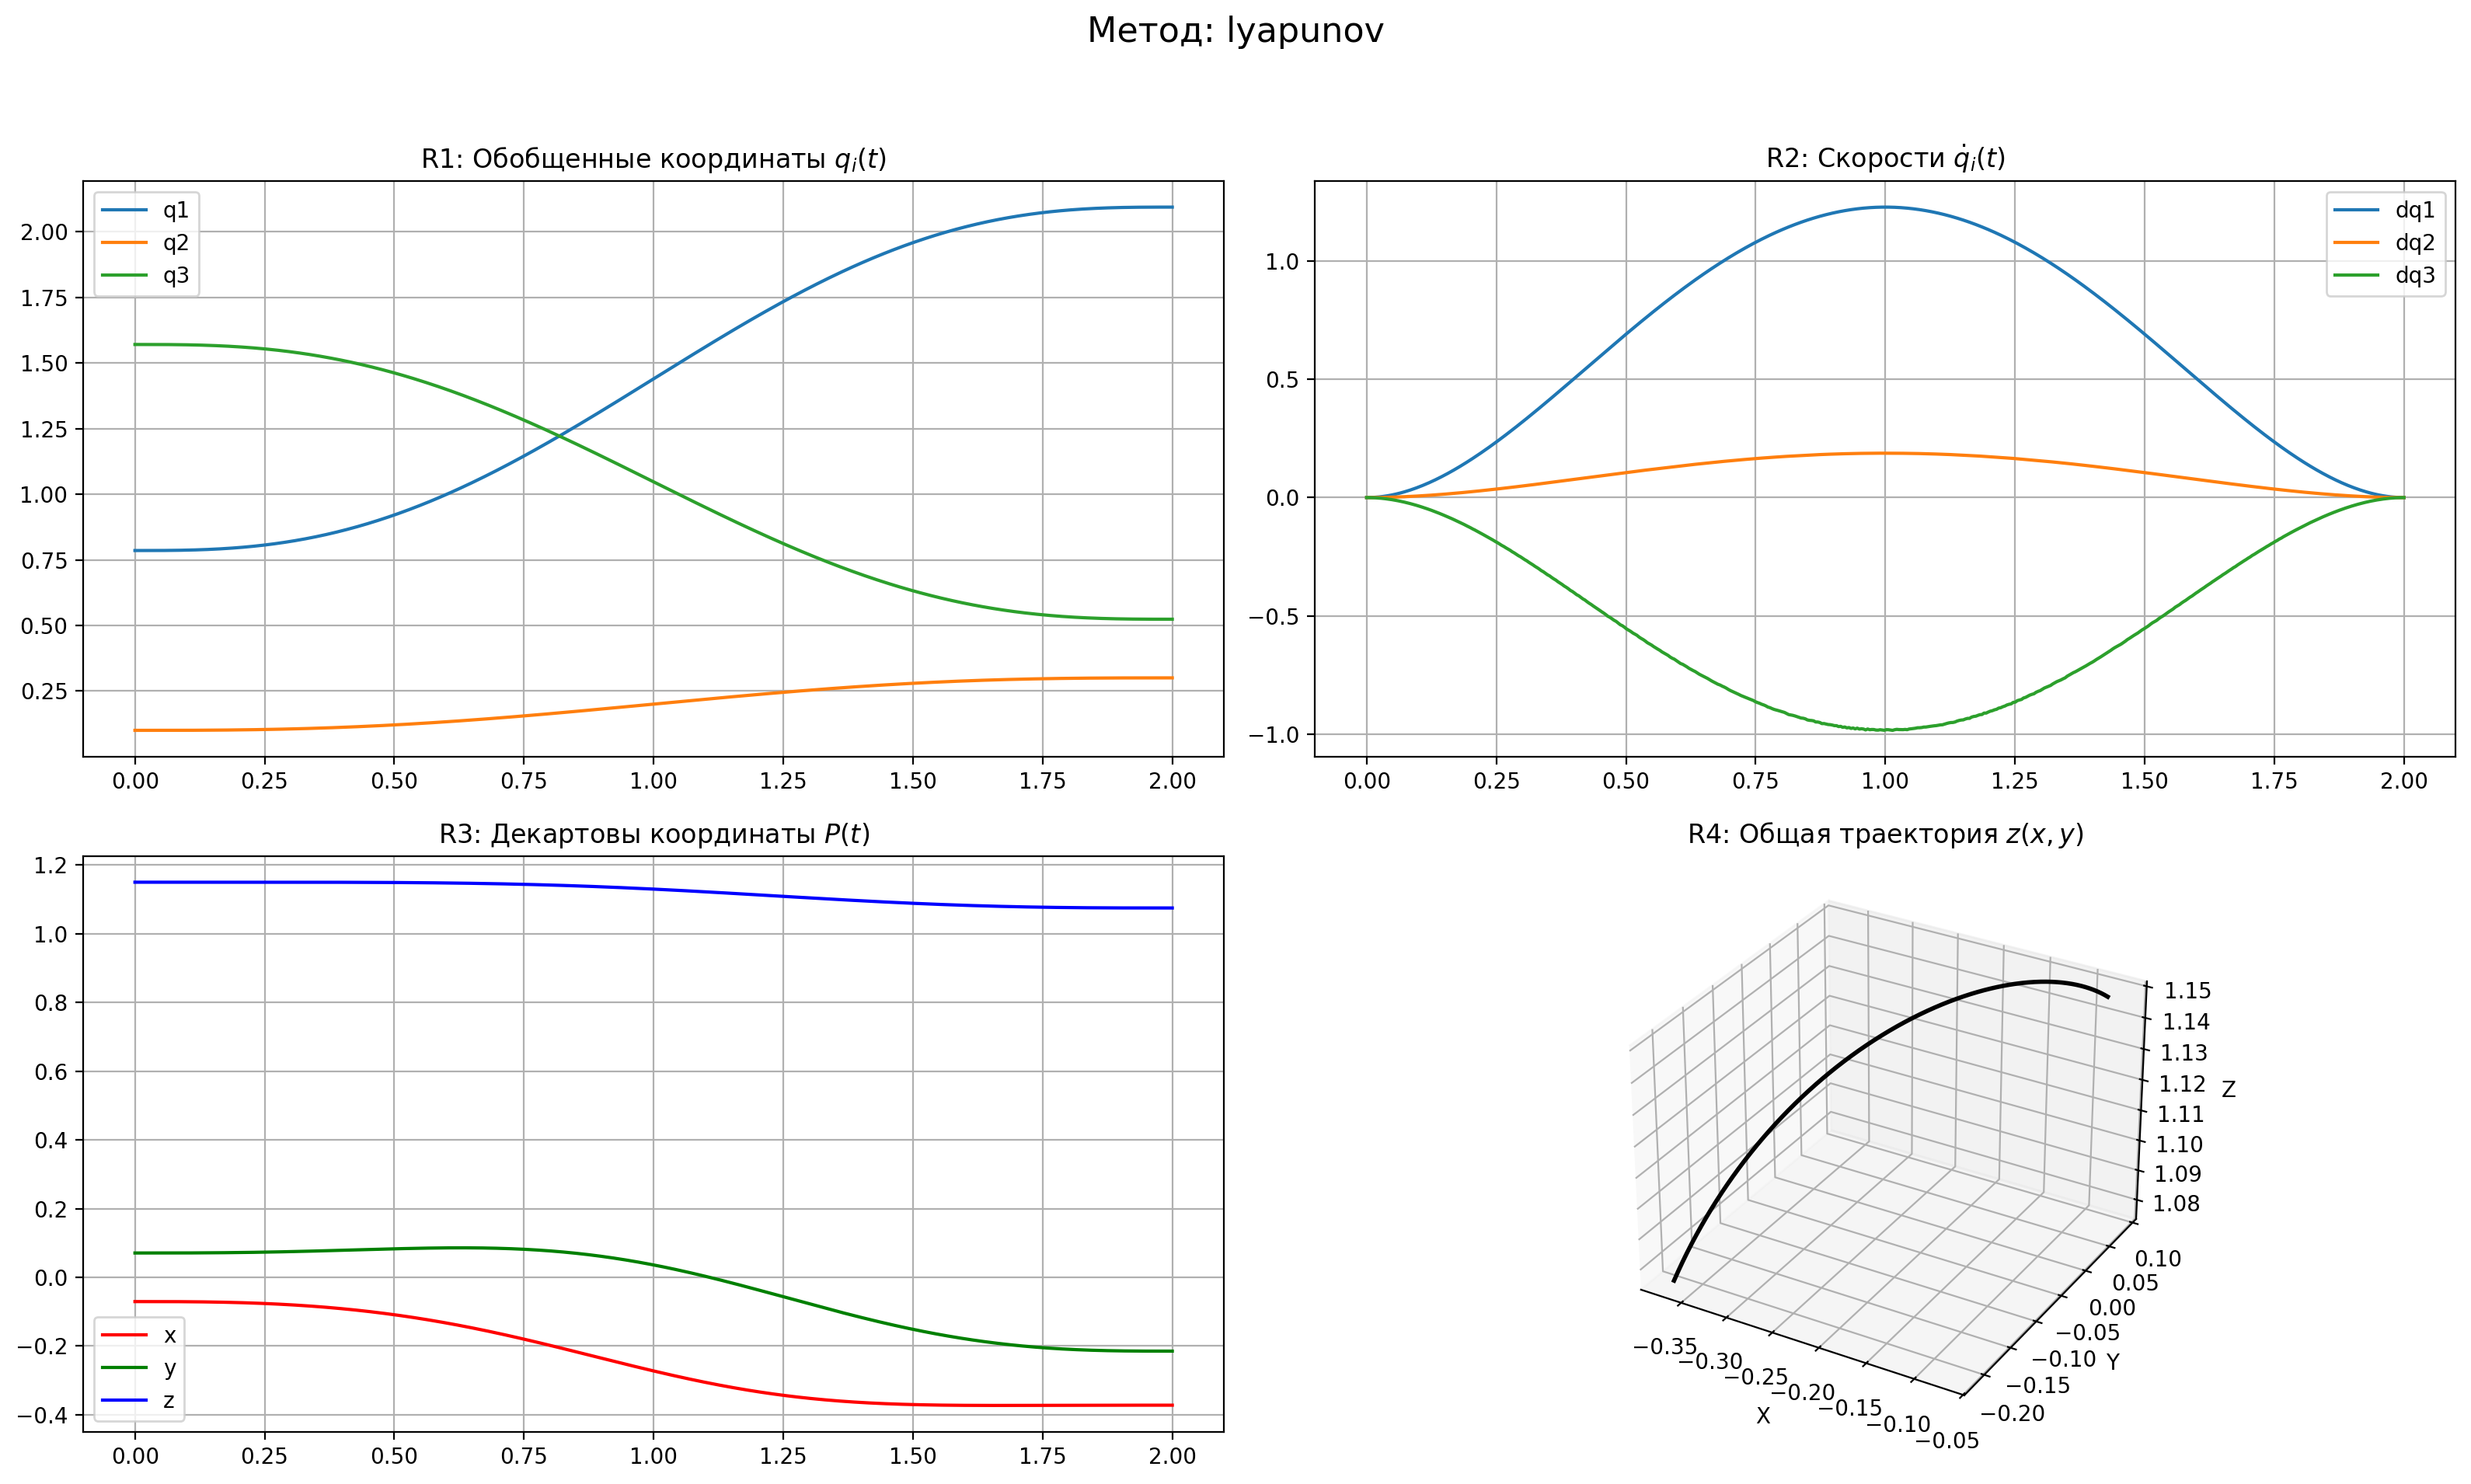

In [4]:
# Моделирование и Визуализация
methods = ['inverse_dynamics', 'lyapunov']
results = {}

for m in methods:
    sol = solve_ivp(robot_ode, [0, T_end], np.concatenate(([np.pi/4, 0.1, np.pi/2], [0,0,0])), t_eval=np.linspace(0, T_end, 500), args=(m,))
    results[m] = sol

def plot_results(sol, title):
    t = sol.t
    q = sol.y[:3].T
    dq = sol.y[3:].T
    p = np.array([forward_kinematics(qi) for qi in q])

    fig = plt.figure(figsize=(16, 10))
    plt.suptitle(title, fontsize=16)

    # R1: Обобщенные координаты
    ax1 = fig.add_subplot(2, 2, 1)
    for i in range(3): ax1.plot(t, q[:, i], label=f'q{i+1}')
    ax1.set_title('R1: Обобщенные координаты $q_i(t)$')
    ax1.legend()
    ax1.grid(True)

    # R2: Скорости
    ax2 = fig.add_subplot(2, 2, 2)
    for i in range(3): ax2.plot(t, dq[:, i], label=f'dq{i+1}')
    ax2.set_title(r'R2: Скорости $\dot{q}_i(t)$')
    ax2.legend();
    ax2.grid(True)

    # R3: Декартовы координаты
    ax3 = fig.add_subplot(2, 2, 3)
    ax3.plot(t, p[:, 0], 'r', label='x')
    ax3.plot(t, p[:, 1], 'g', label='y')
    ax3.plot(t, p[:, 2], 'b', label='z')
    ax3.set_title('R3: Декартовы координаты $P(t)$');
    ax3.legend();
    ax3.grid(True)

    # R4: 3D траектория
    ax4 = fig.add_subplot(2, 2, 4, projection='3d')
    ax4.plot(p[:, 0], p[:, 1], p[:, 2], 'black', lw=2)
    ax4.set_title('R4: Общая траектория $z(x, y)$')
    ax4.set_xlabel('X')
    ax4.set_ylabel('Y')
    ax4.set_zlabel('Z')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

for m in methods:
    plot_results(results[m], f"Метод: {m}")